# Decision Tree — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

Fourth philosophy: no gradients, no stored neighbors, no count tables — **learning is asking the best questions** (README §3.3). The entire model will be ~40 lines: an impurity ruler, a question-scorer, and a recursion.

In [1]:
# Block 1 — Imports. NumPy and recursion. That's the toolbox.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(33)

## Block 2 — Look at the data BEFORE modeling *(README §1, §2.1)*

Poisonous = (big cap AND low spores) OR (small cap AND high spores) — an XOR pattern. Hold this thought: **no straight line can separate these classes** (README fig 04 shows lesson 02 scoring 64% here). The tree's belief — classes live in boxes — is exactly what this data needs.

   cap_cm  spore_density      label
0     7.8           4.07     edible
1     9.4           4.53     edible
2    13.8           6.53     edible
3     5.3           8.52  poisonous
4     9.7           3.14     edible 

300 mushrooms | {'edible': 151, 'poisonous': 149}


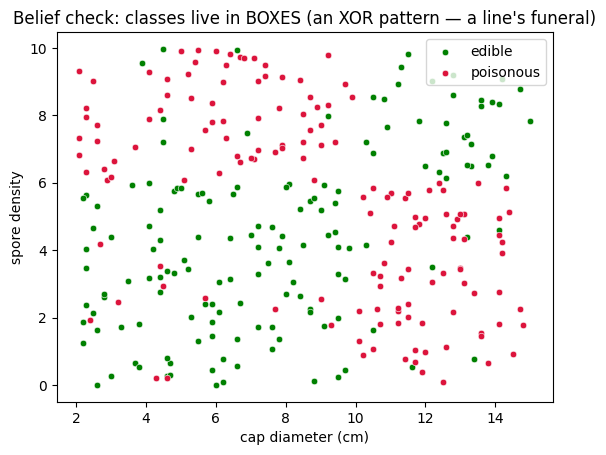

train: 240 | test: 60


In [2]:
df = pd.read_csv("data/mushroom_data.csv")
print(df.head(), f"\n\n{len(df)} mushrooms | {df.label.value_counts().to_dict()}")

X = df[["cap_cm", "spore_density"]].values
y = (df.label == "poisonous").astype(int).values

plt.scatter(X[y==0,0], X[y==0,1], color="green", s=22, label="edible", edgecolor="white", lw=0.4)
plt.scatter(X[y==1,0], X[y==1,1], color="crimson", s=22, label="poisonous", edgecolor="white", lw=0.4)
plt.xlabel("cap diameter (cm)"); plt.ylabel("spore density"); plt.legend()
plt.title("Belief check: classes live in BOXES (an XOR pattern — a line's funeral)")
plt.show()

# Train/test split, the lesson 03 rule — the exam stays sealed.
idx = np.random.permutation(len(y))
cut = int(0.8 * len(y))
tr, te = idx[:cut], idx[cut:]
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"train: {len(tr)} | test: {len(te)}")

## Block 3 — Feature scaling: NOT NEEDED. Enjoy this block. *(README §4)*

"Is cap_cm <= 10?" gives the same answer in centimeters, meters, or lightyears — the threshold just changes units with the feature. First model in the course that is immune to the canyon problem (lesson 01 §4) AND the blind-ruler problem (lesson 03 §2.2). This near-empty block is the celebration.

In [3]:
# (intentionally no real code — the absence IS the lesson)
print("No scaling. Trees ask threshold questions; units cancel out. README §4.")

No scaling. Trees ask threshold questions; units cancel out. README §4.


## Block 4 — The impurity ruler *(README §3.1)*

Gini = the chance that two randomly drawn mushrooms from a pile disagree. Pure pile → 0. Coin-flip pile → 0.5. This one number lets us compare questions.

In [4]:
def gini(y):
    """README §3.1 — how mixed is this pile?"""
    if len(y) == 0:
        return 0.0
    p = y.mean()                     # fraction poisonous
    return 1 - p**2 - (1 - p)**2

print(f"all-edible pile:    {gini(np.array([0,0,0,0])):.2f}   (everyone agrees)")
print(f"coin-flip pile:     {gini(np.array([0,1,0,1])):.2f}   (maximum confusion)")
print(f"our training pile:  {gini(ytr):.2f}   (nearly 50/50 — lots of un-mixing to do)")

all-edible pile:    0.00   (everyone agrees)
coin-flip pile:     0.50   (maximum confusion)
our training pile:  0.50   (nearly 50/50 — lots of un-mixing to do)


## Block 5 — Scoring questions: try EVERYTHING, keep the best un-mixer *(README §3.2)*

Gain(question) = parent impurity − size-weighted average of the children's impurities. The algorithm is honest brute force: every feature, every threshold.

In [5]:
def best_split(X, y):
    """README §3.2 — exhaustively find the question with the biggest impurity drop."""
    base, best = gini(y), None
    for f in range(X.shape[1]):                        # every feature...
        for t in np.unique(X[:, f]):                   # ...every threshold it takes
            left = X[:, f] <= t
            if left.sum() == 0 or (~left).sum() == 0:
                continue                               # a question everyone answers the same way asks nothing
            child_mix = left.mean()*gini(y[left]) + (~left).mean()*gini(y[~left])
            gain = base - child_mix
            if best is None or gain > best[0]:
                best = (gain, f, t)
    return best

FEAT = ["cap_cm", "spore_density"]
g, f, t = best_split(Xtr, ytr)
print(f"The single best first question: '{FEAT[f]} <= {t}?'   (gain = {g:.3f})")
print("Modest gain — on XOR-ish data no ONE question can do much (README §3.3, greedy).")
print("The magic is in the RECURSION: the children's questions crack it.")

The single best first question: 'spore_density <= 4.72?'   (gain = 0.030)
Modest gain — on XOR-ish data no ONE question can do much (README §3.3, greedy).
The magic is in the RECURSION: the children's questions crack it.


## Block 6 — Grow the tree: recursion + stopping rules *(README §3.3)*

grow(pile): if pure/tiny/deep-enough → leaf (majority verdict). Else: ask the best question, grow(left), grow(right). Then we print the learned flowchart — a model you can read aloud.

In [6]:
def grow(X, y, depth=0, max_depth=4, min_leaf=3):
    """README §3.3 — the whole training algorithm."""
    if depth >= max_depth or len(np.unique(y)) == 1 or len(y) < 2 * min_leaf:
        return {"leaf": True, "pred": int(round(y.mean())), "p": y.mean(), "n": len(y)}
    s = best_split(X, y)
    if s is None or s[0] <= 1e-12:                     # no question helps -> give a verdict
        return {"leaf": True, "pred": int(round(y.mean())), "p": y.mean(), "n": len(y)}
    _, f, t = s
    left = X[:, f] <= t
    return {"leaf": False, "f": f, "t": t,
            "L": grow(X[left], y[left], depth+1, max_depth, min_leaf),
            "R": grow(X[~left], y[~left], depth+1, max_depth, min_leaf)}

def show(node, indent=""):
    """README §5 — the model IS its explanation."""
    if node["leaf"]:
        verdict = "POISONOUS" if node["pred"] == 1 else "EDIBLE"
        conf = max(node["p"], 1 - node["p"])
        print(f"{indent}-> {verdict}   ({node['n']} mushrooms, {conf:.0%} pure)")
    else:
        print(f"{indent}{FEAT[node['f']]} <= {node['t']}?")
        print(f"{indent} YES:"); show(node["L"], indent + "   ")
        print(f"{indent} NO :"); show(node["R"], indent + "   ")

tree = grow(Xtr, ytr, max_depth=4)
show(tree)

spore_density <= 4.72?
 YES:
   cap_cm <= 9.7?
    YES:
      spore_density <= 0.21?
       YES:
         -> EDIBLE   (4 mushrooms, 50% pure)
       NO :
         cap_cm <= 4.5?
          YES:
            -> EDIBLE   (26 mushrooms, 81% pure)
          NO :
            -> EDIBLE   (46 mushrooms, 96% pure)
    NO :
      spore_density <= 3.47?
       YES:
         spore_density <= 0.52?
          YES:
            -> POISONOUS   (3 mushrooms, 67% pure)
          NO :
            -> POISONOUS   (27 mushrooms, 96% pure)
       NO :
         cap_cm <= 12.2?
          YES:
            -> EDIBLE   (2 mushrooms, 100% pure)
          NO :
            -> POISONOUS   (6 mushrooms, 67% pure)
 NO :
   cap_cm <= 9.2?
    YES:
      spore_density <= 5.98?
       YES:
         -> EDIBLE   (15 mushrooms, 100% pure)
       NO :
         spore_density <= 9.93?
          YES:
            -> POISONOUS   (58 mushrooms, 95% pure)
          NO :
            -> EDIBLE   (2 mushrooms, 100% pure)
    NO :
      s

## Block 7 — Predict and grade on the sealed exam *(README §3.4, §5)*

Prediction = walk each mushroom down the questions. O(depth) per prediction — compare lesson 03, which scanned the whole dataset every time.

In [7]:
def tree_predict(node, X):
    """README §3.4 — follow the answers to a leaf; return its verdict."""
    if node["leaf"]:
        return np.full(len(X), node["pred"])
    left = X[:, node["f"]] <= node["t"]
    out = np.empty(len(X), dtype=int)
    out[left]  = tree_predict(node["L"], X[left])
    out[~left] = tree_predict(node["R"], X[~left])
    return out

pred = tree_predict(tree, Xte)
acc = (pred == yte).mean()
TP = int(((pred==1)&(yte==1)).sum()); FP = int(((pred==1)&(yte==0)).sum())
TN = int(((pred==0)&(yte==0)).sum()); FN = int(((pred==0)&(yte==1)).sum())
print(f"Test accuracy: {acc:.0%}   (recall lesson 02's model manages ~64% here — a line cannot do XOR)\n")
print("Confusion              predicted EDIBLE   predicted POISONOUS")
print(f"actually EDIBLE     |       {TN:3d}         |       {FP:3d}")
print(f"actually POISONOUS  |       {FN:3d}         |       {TP:3d}   <- the FN cell is the one that hospitalizes people")

Test accuracy: 85%   (recall lesson 02's model manages ~64% here — a line cannot do XOR)

Confusion              predicted EDIBLE   predicted POISONOUS
actually EDIBLE     |        25         |         3
actually POISONOUS  |         6         |        26   <- the FN cell is the one that hospitalizes people


## Block 8 — The depth U-curve *(README §4 — lesson 03's picture, new knob)*

In lesson 03 the knob was K; here it's max_depth. Train accuracy only rises with depth (more memorization); test accuracy rises, peaks, falls. The gap is overfitting — same picture, as promised.

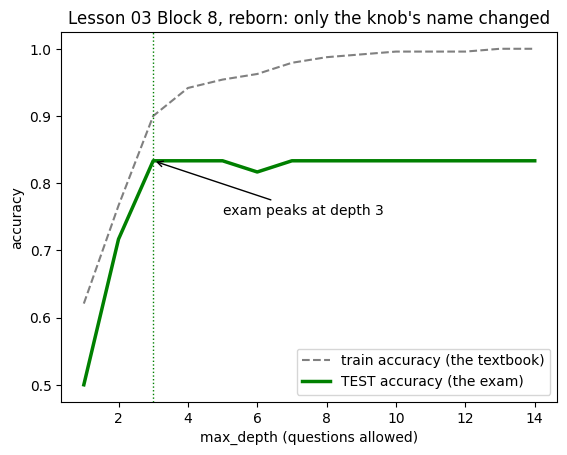

In [8]:
depths = range(1, 15)
tr_acc, te_acc = [], []
for d in depths:
    td = grow(Xtr, ytr, max_depth=d, min_leaf=1)
    tr_acc.append((tree_predict(td, Xtr) == ytr).mean())
    te_acc.append((tree_predict(td, Xte) == yte).mean())

plt.plot(depths, tr_acc, "--", color="gray", label="train accuracy (the textbook)")
plt.plot(depths, te_acc, color="green", lw=2.5, label="TEST accuracy (the exam)")
best_d = list(depths)[int(np.argmax(te_acc))]
plt.axvline(best_d, color="green", ls=":", lw=1)
plt.annotate(f"exam peaks at depth {best_d}", xy=(best_d, max(te_acc)),
             xytext=(best_d+2, max(te_acc)-0.08), arrowprops=dict(arrowstyle="->"))
plt.xlabel("max_depth (questions allowed)"); plt.ylabel("accuracy"); plt.legend(loc="lower right")
plt.title("Lesson 03 Block 8, reborn: only the knob's name changed")
plt.show()

## Block 9 — Break it on purpose: the greedy trap *(README §3.3)*

Greedy pathology, staged: a perfectly SYMMETRIC XOR (boundaries at the exact midpoints, no noise). Now no first question earns real gain — the best possible split improves impurity by ~0.007, about **70x less** than a genuinely useful question. Watch what happens with and without a minimum-gain requirement (a standard regularization — sklearn calls it `min_impurity_decrease`).

In [9]:
rng = np.random.default_rng(0)
Xsym = rng.uniform(0, 1, (400, 2))
ysym = ((Xsym[:,0] > 0.5).astype(int) ^ (Xsym[:,1] > 0.5).astype(int))   # perfect XOR, boundaries at 0.5/0.5

g_sym = best_split(Xsym, ysym)
print(f"Best achievable first-question gain: {g_sym[0]:.4f}   (a USEFUL question gains ~0.5 here)")

def grow_min_gain(X, y, depth=0, max_depth=6, min_leaf=3, min_gain=0.0):
    """grow() with a minimum-gain requirement — sklearn's min_impurity_decrease."""
    if depth >= max_depth or len(np.unique(y)) == 1 or len(y) < 2 * min_leaf:
        return {"leaf": True, "pred": int(round(y.mean()))}
    s = best_split(X, y)
    if s is None or s[0] <= min_gain:                  # "not worth asking" -> give a verdict
        return {"leaf": True, "pred": int(round(y.mean()))}
    _, f, t = s
    left = X[:, f] <= t
    return {"leaf": False, "f": f, "t": t,
            "L": grow_min_gain(X[left], y[left], depth+1, max_depth, min_leaf, min_gain),
            "R": grow_min_gain(X[~left], y[~left], depth+1, max_depth, min_leaf, min_gain)}

for mg in [0.01, 0.0]:
    tsym = grow_min_gain(Xsym, ysym, min_gain=mg)
    acc = (tree_predict(tsym, Xsym) == ysym).mean()
    state = "STALLED at the root — a coin-flip leaf" if tsym["leaf"] else "grew a tree"
    print(f"min_gain={mg}:  accuracy {acc:.0%}  ->  {state}")

print()
print("With ANY sensible minimum-gain bar, greedy quits at the root: it judges questions")
print("ONE AT A TIME, and on symmetric XOR no single question helps (README §3.3, §8 Q6).")
print("With min_gain=0 it survives here only by chasing ~0.007-gain noise crumbs until the")
print("second level cracks the pattern — luck, not insight. Real data is rarely this")
print("adversarial: our mushroom boundaries are off-center, giving greedy an honest foothold.")

Best achievable first-question gain: 0.0074   (a USEFUL question gains ~0.5 here)
min_gain=0.01:  accuracy 55%  ->  STALLED at the root — a coin-flip leaf
min_gain=0.0:  accuracy 100%  ->  grew a tree

With ANY sensible minimum-gain bar, greedy quits at the root: it judges questions
ONE AT A TIME, and on symmetric XOR no single question helps (README §3.3, §8 Q6).
With min_gain=0 it survives here only by chasing ~0.007-gain noise crumbs until the
second level cracks the pattern — luck, not insight. Real data is rarely this
adversarial: our mushroom boundaries are off-center, giving greedy an honest foothold.


## Block 10 — Where does it fail? *(README §6)*

Draw the learned rectangles with the test mistakes on top. Expect errors hugging the box edges and among the 5% noise-flipped labels — the belief held; the world is just noisy.

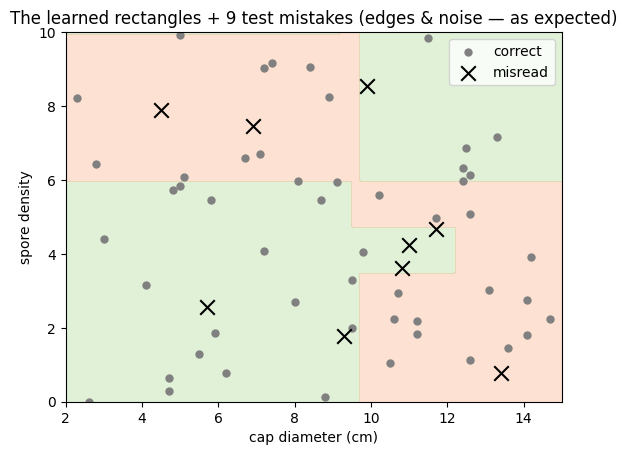

In [10]:
g0, g1 = np.meshgrid(np.linspace(2, 15, 250), np.linspace(0, 10, 250))
Z = tree_predict(tree, np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)
plt.contourf(g0, g1, Z, alpha=0.25, cmap="RdYlGn_r", levels=[-0.5, 0.5, 1.5])
wrong = pred != yte
plt.scatter(Xte[~wrong,0], Xte[~wrong,1], c="gray", s=25, label="correct")
plt.scatter(Xte[wrong,0], Xte[wrong,1], c="black", marker="x", s=110, label="misread")
plt.xlabel("cap diameter (cm)"); plt.ylabel("spore density"); plt.legend()
plt.title(f"The learned rectangles + {wrong.sum()} test mistakes (edges & noise — as expected)")
plt.show()

---
## What you now own

- A fourth way to learn: exhaustive question-trying + greedy recursion — ~40 lines, no gradients
- Gini as "the chance two random members disagree", and gain as "how much a question un-mixes"
- A model that DEFEATS the linear world of lessons 01–02 (XOR), needs no scaling, and can be read aloud
- The depth U-curve — lesson 03's overfitting picture, knob renamed as promised
- The tree's two honest weaknesses: greedy blindness (staged in Block 9) and instability — the reason lesson 06 exists

**Next:** `decision_tree_with_library.ipynb` to verify against sklearn (and see its tree-drawing + feature importances) — then folder `06-random-forest`: many deliberately-different trees, voting.